### Imports Sys

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder

from src.data.loader           import load_all
from src.data.cleaner          import clean_medals, clean_countries
from src.features.builder      import build_features, get_feature_cols
from src.models.regression     import build_rf_regressor, build_gbr, cross_validate_reg
from src.models.classification import build_dominance_labels, build_classifier
from src.models.clustering     import build_kmeans, find_optimal_k
from src.evaluation.metrics    import regression_metrics, classification_metrics

### Load and prepare data


In [2]:
medals_raw, countries_raw = load_all(config_path='../config/config.yaml')
medals    = clean_medals(medals_raw)
countries = clean_countries(countries_raw)
features  = build_features(medals, countries).dropna()
feat_cols = get_feature_cols(features)
X = features[feat_cols].values
y = features['TotalMedals'].values
print('X shape:', X.shape)
print('y shape:', y.shape)

✅ Medals loaded: (36935, 12) | Countries: (201, 5)
   Summer records : 31,165
   Winter records : 5,770
   Project root used: C:\Users\ACER\OneDrive\Desktop\Bull\Olympics-ML-Analysis
X shape: (1447, 6)
y shape: (1447,)


### Train / test split


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (1157, 6)
Test size : (290, 6)


### Train Random Forest Regressor


In [4]:
rf = build_rf_regressor()
rf.fit(X_train, y_train)
print('Random Forest trained.')

Random Forest trained.


### RF cross validation

In [5]:
cv_scores = cross_validate_reg(rf, X, y)
print('CV RMSE mean:', cv_scores['rmse_mean'])
print('CV RMSE std :', cv_scores['rmse_std'])

CV RMSE mean: 10.52
CV RMSE std : 8.4319


### RF test metrics


In [6]:
mets = regression_metrics(y_test, rf.predict(X_test))
print('RMSE:', mets['rmse'])
print('MAE :', mets['mae'])
print('R2  :', mets['r2'])

RMSE: 6.0173
MAE : 3.0156
R2  : 0.9543


### Train Gradient Boosting Regressor


In [7]:
gbr = build_gbr()
gbr.fit(X_train, y_train)
gbr_mets = regression_metrics(y_test, gbr.predict(X_test))
print('GBR  RMSE:', gbr_mets['rmse'], ' R2:', gbr_mets['r2'])

GBR  RMSE: 4.1388  R2: 0.9784


### Compare RF vs GBR


In [8]:
print(f"{'Model':<30} {'RMSE':<10} {'R2'}")
print(f"{'Random Forest':<30} {mets['rmse']:<10} {mets['r2']}")
print(f"{'Gradient Boosting':<30} {gbr_mets['rmse']:<10} {gbr_mets['r2']}")

Model                          RMSE       R2
Random Forest                  6.0173     0.9543
Gradient Boosting              4.1388     0.9784


### Feature importance


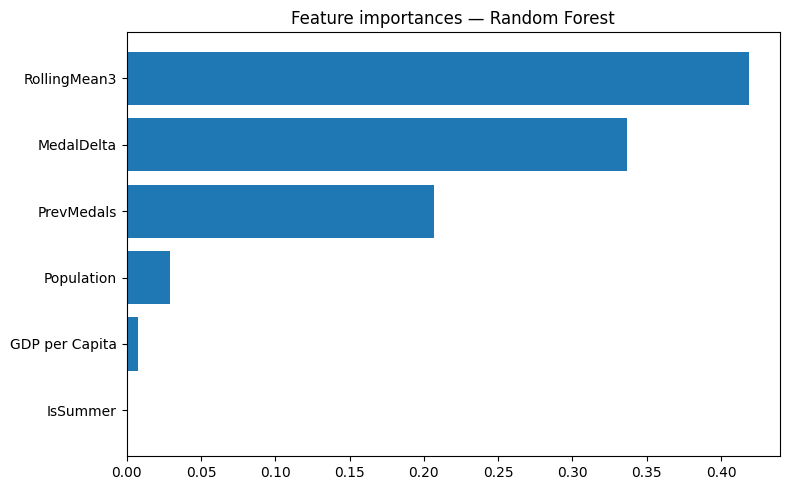

In [9]:
importances = rf.feature_importances_
indices     = importances.argsort()[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([feat_cols[i] for i in indices[::-1]],
        importances[indices[::-1]])
ax.set_title('Feature importances — Random Forest')
plt.tight_layout()
plt.show()

### Actual vs predicted


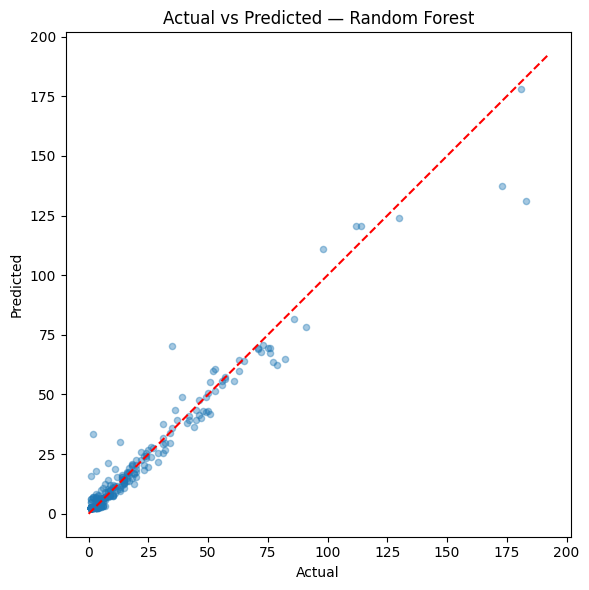

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, rf.predict(X_test), alpha=0.4, s=20)
lim = max(y_test.max(), rf.predict(X_test).max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('Actual vs Predicted — Random Forest')
plt.tight_layout()
plt.show()

### Classification model


In [11]:
dom      = build_dominance_labels(medals)
feat_cls = features.merge(dom, on=['Country','Year'], how='inner').dropna()
fc       = get_feature_cols(feat_cls)
Xc       = feat_cls[fc].values
le       = LabelEncoder()
yc       = le.fit_transform(feat_cls['TopSport'])
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.2, random_state=42)
clf = build_classifier()
clf.fit(Xc_tr, yc_tr)
clf_mets = classification_metrics(yc_te, clf.predict(Xc_te))
print('Classification accuracy:', clf_mets['accuracy'])

Classification accuracy: 0.3211


c:\Users\ACER\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ACER\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ACER\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shap

### Find optimal k for clustering


c:\Users\ACER\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ACER\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ACER\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ACER\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: User

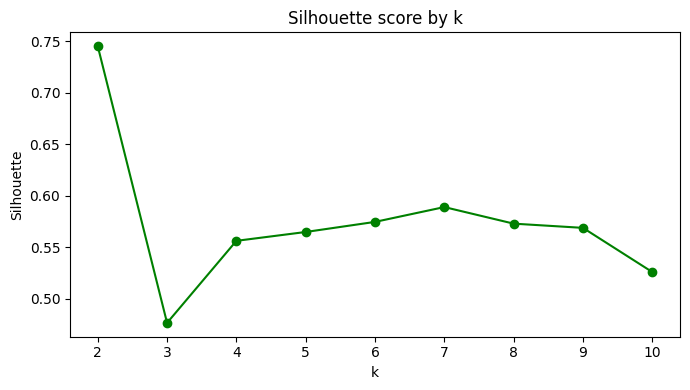

In [12]:
country_agg = features.groupby('Country')[feat_cols].mean().dropna().reset_index()
Xk          = country_agg[feat_cols].values
k_scores    = find_optimal_k(Xk)
ks          = sorted(k_scores.keys())
silhouettes = [k_scores[k]['silhouette'] for k in ks]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, silhouettes, marker='o', color='green')
ax.set_title('Silhouette score by k')
ax.set_xlabel('k')
ax.set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

### Train KMeans with best k


In [13]:
best_k = max(k_scores, key=lambda k: k_scores[k]['silhouette'])
print('Best k:', best_k)
km = build_kmeans(n_clusters=best_k)
km.fit(Xk)
country_agg['Cluster'] = km.named_steps['kmeans'].labels_
print(country_agg[['Country','Cluster']].head(10))

Best k: 2
       Country  Cluster
0          AUS        0
1          AUT        0
2  Afghanistan        0
3      Algeria        0
4    Argentina        0
5      Armenia        0
6    Australia        0
7      Austria        0
8   Azerbaijan        0
9          BEL        0


c:\Users\ACER\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Save all models


In [14]:
import os
os.makedirs('../models/trained', exist_ok=True)
joblib.dump(rf,  '../models/trained/regression_rf.pkl')
joblib.dump(clf, '../models/trained/classification_rf.pkl')
joblib.dump(km,  '../models/trained/clustering_kmeans.pkl')
joblib.dump(le,  '../models/trained/label_encoder.pkl')
print('All models saved.')

All models saved.
